In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd

%matplotlib widget
import cyl_lvm as clvm
from experiment.synthetic_data import experiment_helper as mod
import matplotlib.pyplot as plt


rng = np.random.RandomState(7)
D_GAUSS = mod.D_GAUSS
D_VMF = mod.D_VMF
N = 10000

In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        norm = np.linalg.norm(v)
        return v / max(norm, 1e-12)
    else:
        norm = np.linalg.norm(v, axis=-1, keepdims=True)
        return v / np.clip(norm, 1e-12, None)

In [3]:
# Mixture of Cylindrical distributions (d=3, d=3)
cyl_components = [
    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),
        cross_cov=np.array([[ 0.45, -0.10,  0.20],
                            [ 0.05,  0.30, -0.15],
                            [-0.25,  0.10,  0.35]]),
        cond_cov=np.array([[2.20, 0.75, 0.40],
                           [0.75, 0.55, 0.10],
                           [0.40, 0.10, 0.25]]),
        mu_vmf=unit([1.0, 0.0, 0.0]),
        kappa=9.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),   # same Gaussian mean
        cross_cov=np.array([[-0.30,  0.20,  0.10],
                            [ 0.15, -0.25,  0.05],
                            [ 0.10,  0.05, -0.20]]),
        cond_cov=np.array([[0.75, 0.05, 0.00],
                           [0.05, 0.85, 0.08],
                           [0.00, 0.08, 0.70]]),   # much more isotropic
        mu_vmf=unit([0.0, 1.0, 0.0]),
        kappa=9.0,
    ),

    clvm.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([2.3, 1.2, -1.0]),
        cross_cov=np.array([[ 0.10,  0.15, -0.20],
                            [-0.05,  0.25,  0.18],
                            [ 0.20, -0.10,  0.12]]),
        cond_cov=np.array([[0.95, 0.18, -0.05],
                           [0.18, 1.05, 0.12],
                           [-0.05, 0.12, 0.80]]),
        mu_vmf=unit([0.0, 0.0, 1.0]),
        kappa=5.5,
    ),
]

cyl_weights = np.array([0.35, 0.35, 0.30], dtype=float)

generator = clvm.MixtureModel(components=cyl_components,
                              weights=cyl_weights,
                              init="k-means",
                              rng=rng)

x = generator.sample(N, rng=rng)

In [4]:
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

In [5]:
# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

In [6]:
kmeans = clvm.CylindricalKMeans(3, lambda_=1)
kmeans.fit(x_gauss, x_vmf)
labels = kmeans.predict(x_gauss, x_vmf)

In [7]:
res = {i: (labels == i).sum()/labels.shape[0] for i in range(3)}
res

{0: 0.2961, 1: 0.3428, 2: 0.3611}

In [8]:
def plot_3d_labeled_scatter(
    X,
    y,
    true_centroids=None,          # new
    title="3D Scatter by Label",
    s=24,
    alpha=0.85,
    centroid_size=260
):
    from matplotlib import colormaps

    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim != 2 or X.shape[1] != 3:
        raise ValueError(f"X must have shape (n_samples, 3), got {X.shape}")
    if y.shape[0] != X.shape[0]:
        raise ValueError("y must have same number of samples as X")

    labels = np.unique(y)
    data_cmap = colormaps["tab20"].resampled(len(labels))

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Data points by label
    for i, lab in enumerate(labels):
        m = (y == lab)
        ax.scatter(
            X[m, 0], X[m, 1], X[m, 2],
            s=s, alpha=alpha, color=data_cmap(i), label=f"Label {lab}"
        )

    # True centroids (bigger, solid, different colors)
    if true_centroids is not None:
        C = np.asarray(true_centroids)
        if C.ndim != 2 or C.shape[1] != 3:
            raise ValueError(f"true_centroids must have shape (n_centroids, 3), got {C.shape}")

        cent_cmap = colormaps["Set1"].resampled(C.shape[0])
        for j in range(C.shape[0]):
            ax.scatter(
                C[j, 0], C[j, 1], C[j, 2],
                s=centroid_size,
                color=cent_cmap(j),
                alpha=1.0,
                marker="o",
                edgecolor="black",
                linewidths=1.2,
                label=f"True centroid {j}"
            )

    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("X3")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

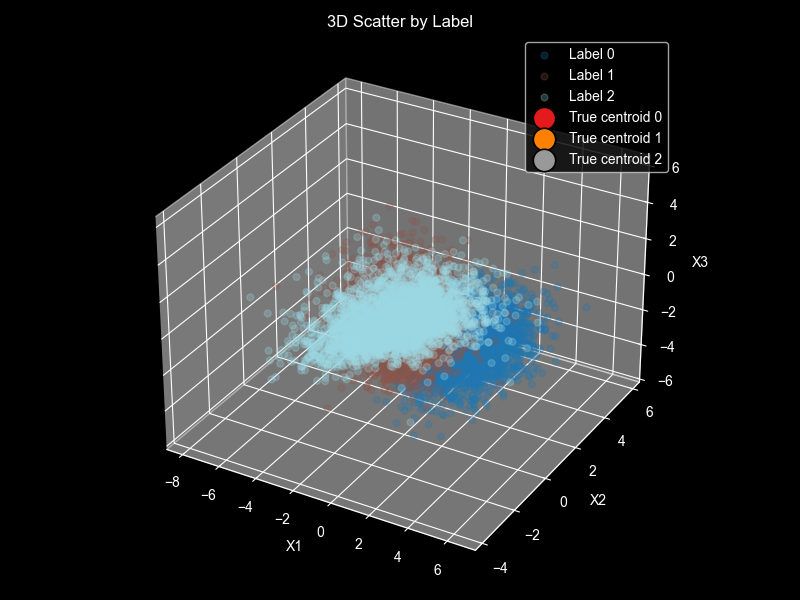

In [9]:
plot_3d_labeled_scatter(x_gauss, labels,
                        alpha=0.25,
                        true_centroids = [[0.0, 0.0, 0.0],
                                          [0.0, 0.0, 0.0],
                                          [2.3, 1.2, -1.0]])

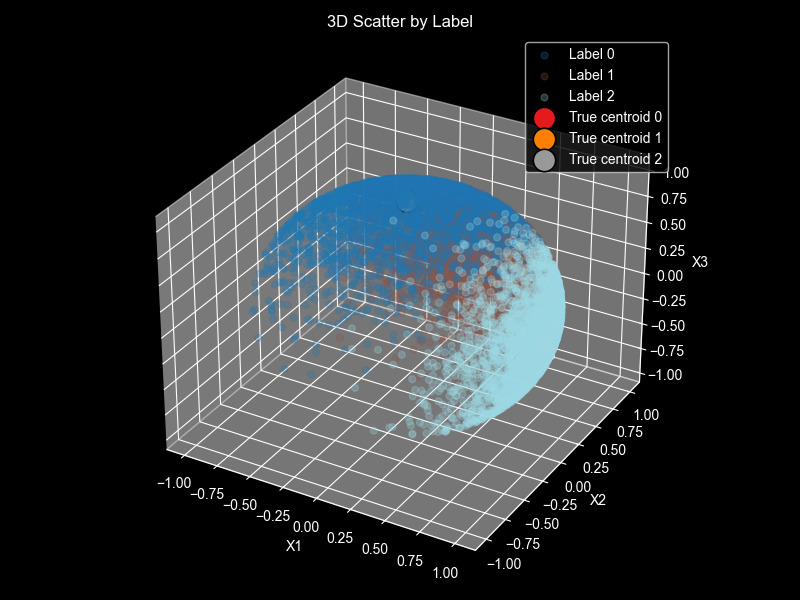

In [10]:
plot_3d_labeled_scatter(x_vmf, labels,
                        alpha=0.25,
                        true_centroids = [[1.0, 0.0, 0.0],
                                          [0.0, 1.0, 0.0],
                                          [0.0, 0.0, 1.0]])